# European Bank — Customer Churn Analysis
### Phase 1 — Data Ingestion & Validation
Load dataset · validate engagement and product fields · ensure binary consistency · confirm churn labeling accuracy
---
**Dataset:** `European_Bank.csv` — 10,000 customers, 14 features

In [1]:
# ── Core imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F9F9F7',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
    'axes.grid':        True,
    'grid.color':       '#E8E6DE',
    'grid.linewidth':   0.6,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
})

PALETTE = {
    'blue':   '#3B8BD4',
    'teal':   '#1D9E75',
    'amber':  '#EF9F27',
    'coral':  '#D85A30',
    'purple': '#7F77DD',
    'red':    '#E24B4A',
    'gray':   '#888780',
    'green':  '#639922',
    'pink':   '#D4537E',
}

print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
df = pd.read_csv('European_Bank.csv')

print(f'Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory usage   : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print()
df.head()

Shape          : 10,000 rows × 14 columns
Memory usage   : 2464.5 KB



,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


---
## Phase 1 — Data Ingestion & Validation

### 1.2 — Schema & Data Types

In [3]:
schema = pd.DataFrame({
    'dtype':        df.dtypes,
    'non_null':     df.notnull().sum(),
    'null_count':   df.isnull().sum(),
    'null_%':       (df.isnull().mean() * 100).round(2),
    'unique_vals':  df.nunique(),
    'sample':       df.iloc[0]
})

schema

,dtype,non_null,null_count,null_%,unique_vals,sample
Year,int64,10000,0,0.0,1,2025
CustomerId,int64,10000,0,0.0,10000,15634602
Surname,object,10000,0,0.0,2932,Hargrave
CreditScore,int64,10000,0,0.0,460,619
Geography,object,10000,0,0.0,3,France
Gender,object,10000,0,0.0,2,Female
Age,int64,10000,0,0.0,70,42
Tenure,int64,10000,0,0.0,11,2
Balance,float64,10000,0,0.0,6382,0.0
NumOfProducts,int64,10000,0,0.0,4,1


### 1.3 — Validate Binary Fields

In [4]:
BINARY_COLS = ['HasCrCard', 'IsActiveMember', 'Exited']

print('Binary field validation')
print('─' * 45)
all_valid = True
for col in BINARY_COLS:
    vals   = set(df[col].unique())
    valid  = vals <= {0, 1}
    status = '✓ PASS' if valid else '✗ FAIL'
    if not valid:
        all_valid = False
    print(f'  {col:<20} values={sorted(vals)}   {status}')

print()
print(f'Overall binary consistency: {"✓ All valid" if all_valid else "✗ Issues found"}')

Binary field validation
─────────────────────────────────────────────
  HasCrCard            values=[np.int64(0), np.int64(1)]   ✓ PASS
  IsActiveMember       values=[np.int64(0), np.int64(1)]   ✓ PASS
  Exited               values=[np.int64(0), np.int64(1)]   ✓ PASS

Overall binary consistency: ✓ All valid


### 1.4 — Numeric Range Validation

In [5]:
RANGE_RULES = {
    'CreditScore':     (300,  850),
    'Age':             (18,   100),
    'Tenure':          (0,    10),
    'Balance':         (0,    None),
    'NumOfProducts':   (1,    4),
    'EstimatedSalary': (0,    None),
}

print('Numeric range validation')
print('─' * 55)
for col, (lo, hi) in RANGE_RULES.items():
    lo_fail = (df[col] < lo).sum() if lo is not None else 0
    hi_fail = (df[col] > hi).sum() if hi is not None else 0
    total_fail = lo_fail + hi_fail
    bounds = f'[{lo}, {hi if hi else "∞"}]'
    status = '✓ PASS' if total_fail == 0 else f'✗ {total_fail} violations'
    print(f'  {col:<22} {bounds:<15} {status}')

# Duplicate check
print()
print(f'Duplicate rows       : {df.duplicated().sum()}')
print(f'Duplicate CustomerIds: {df["CustomerId"].duplicated().sum()}')

Numeric range validation
───────────────────────────────────────────────────────
  CreditScore            [300, 850]      ✓ PASS
  Age                    [18, 100]       ✓ PASS
  Tenure                 [0, 10]         ✓ PASS
  Balance                [0, ∞]          ✓ PASS
  NumOfProducts          [1, 4]          ✓ PASS
  EstimatedSalary        [0, ∞]          ✓ PASS

Duplicate rows       : 0
Duplicate CustomerIds: 0


### 1.5 — Descriptive Statistics

In [ ]:
df.describe(include='all').T

### 1.6 — Churn Label Distribution

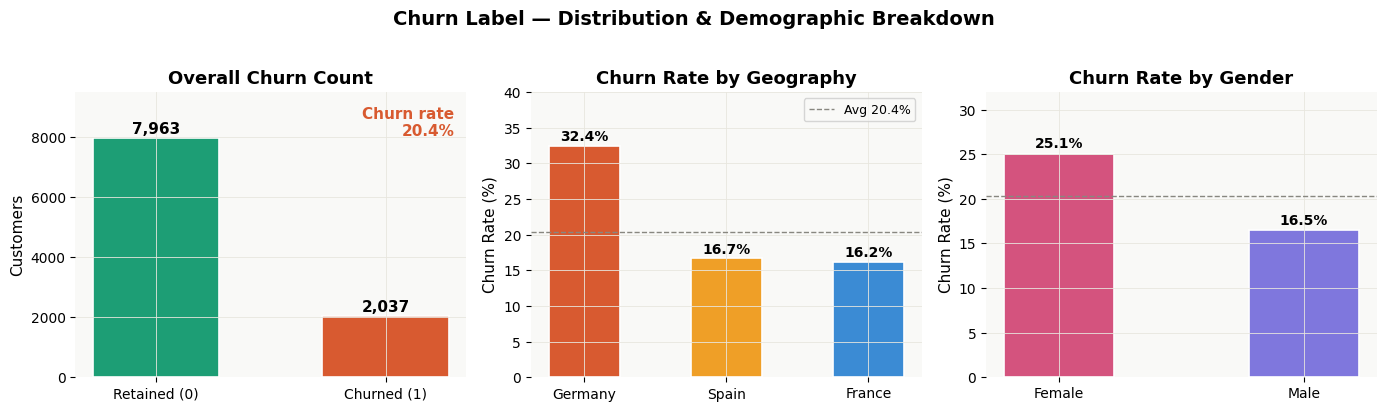


Churn summary:
  Retained : 7,963  (79.6%)
  Churned  : 2,037  (20.4%)
  Class ratio (retained:churned) ≈ 3.9:1


In [6]:
churn_counts = df['Exited'].value_counts()
churn_rate   = df['Exited'].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Churn Label — Distribution & Demographic Breakdown', fontsize=14, fontweight='bold', y=1.02)

# ── Panel 1: Churn counts ──
ax = axes[0]
bars = ax.bar(['Retained (0)', 'Churned (1)'],
              [churn_counts[0], churn_counts[1]],
              color=[PALETTE['teal'], PALETTE['coral']],
              width=0.55, edgecolor='white', linewidth=1.2)
ax.set_title('Overall Churn Count')
ax.set_ylabel('Customers')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
            f'{bar.get_height():,}', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylim(0, 9500)
ax.text(0.97, 0.95, f'Churn rate\n{churn_rate:.1f}%',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=11, color=PALETTE['coral'], fontweight='bold')

# ── Panel 2: Churn by Geography ──
ax = axes[1]
geo_churn = df.groupby('Geography')['Exited'].mean().sort_values(ascending=False) * 100
bars2 = ax.bar(geo_churn.index, geo_churn.values,
               color=[PALETTE['coral'], PALETTE['amber'], PALETTE['blue']],
               width=0.5, edgecolor='white', linewidth=1.2)
ax.set_title('Churn Rate by Geography')
ax.set_ylabel('Churn Rate (%)')
ax.axhline(churn_rate, color=PALETTE['gray'], linestyle='--', linewidth=1, label=f'Avg {churn_rate:.1f}%')
ax.legend(fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, 40)

# ── Panel 3: Churn by Gender ──
ax = axes[2]
gen_churn = df.groupby('Gender')['Exited'].mean() * 100
bars3 = ax.bar(gen_churn.index, gen_churn.values,
               color=[PALETTE['pink'], PALETTE['purple']],
               width=0.45, edgecolor='white', linewidth=1.2)
ax.set_title('Churn Rate by Gender')
ax.set_ylabel('Churn Rate (%)')
ax.axhline(churn_rate, color=PALETTE['gray'], linestyle='--', linewidth=1)
for bar in bars3:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, 32)

plt.tight_layout()
plt.savefig('fig_01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nChurn summary:')
print(f'  Retained : {churn_counts[0]:,}  ({100-churn_rate:.1f}%)')
print(f'  Churned  : {churn_counts[1]:,}  ({churn_rate:.1f}%)')
print(f'  Class ratio (retained:churned) ≈ {(churn_counts[0]/churn_counts[1]):.1f}:1')

### 1.7 — Feature Distribution Overview

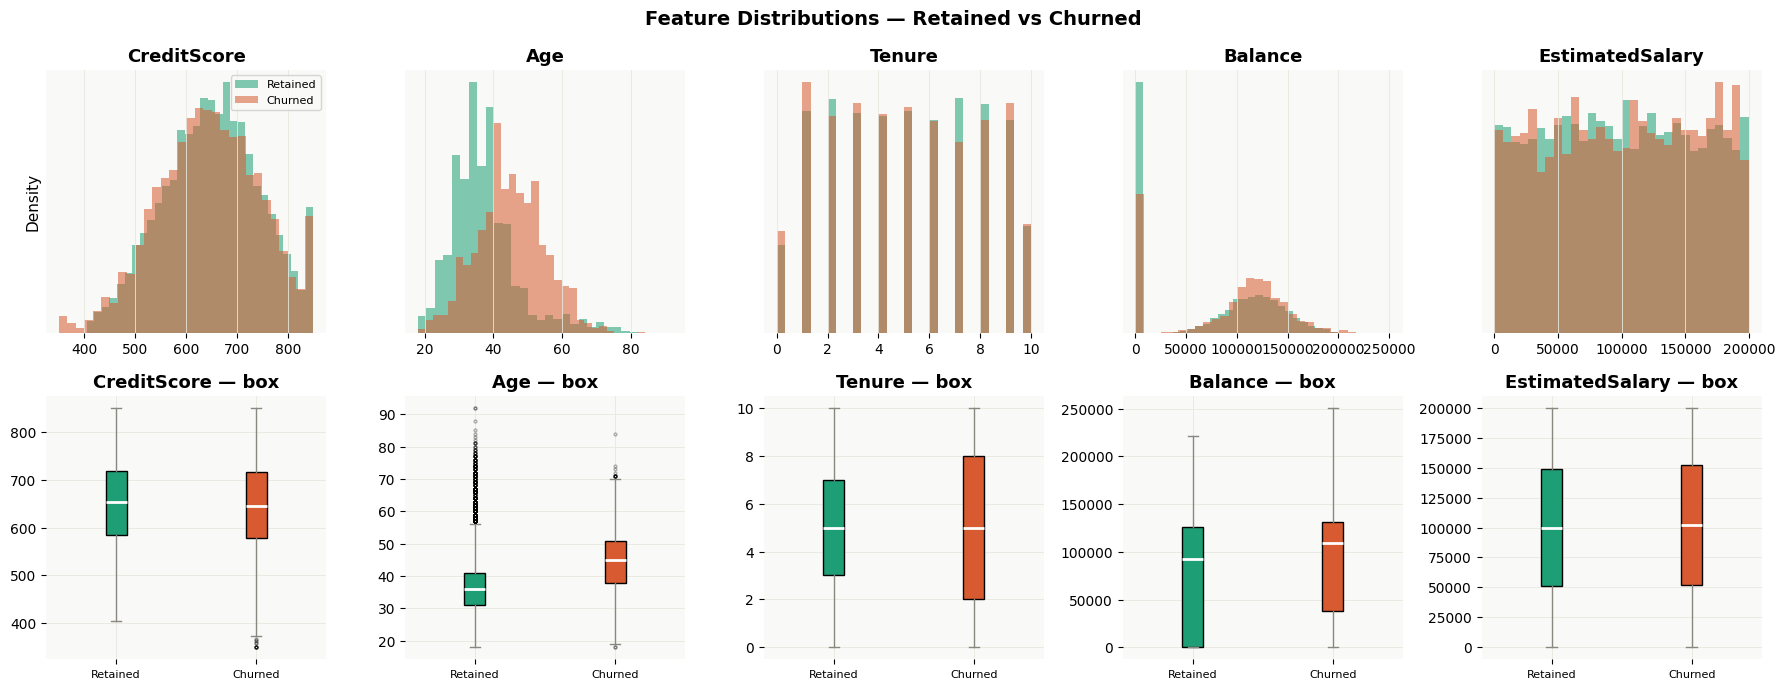

In [8]:
NUM_COLS = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Feature Distributions — Retained vs Churned', fontsize=14, fontweight='bold')

retained = df[df['Exited'] == 0]
churned  = df[df['Exited'] == 1]

for i, col in enumerate(NUM_COLS):
    # Row 0: KDE overlaid
    ax = axes[0, i]
    ax.hist(retained[col], bins=30, color=PALETTE['teal'],  alpha=0.55, label='Retained', density=True)
    ax.hist(churned[col],  bins=30, color=PALETTE['coral'], alpha=0.55, label='Churned',  density=True)
    ax.set_title(col)
    ax.set_yticks([])
    if i == 0:
        ax.set_ylabel('Density')
        ax.legend(fontsize=8)

    # Row 1: Box plot
    ax2 = axes[1, i]
    bp = ax2.boxplot(
        [retained[col].values, churned[col].values],
        labels=['Retained', 'Churned'],
        patch_artist=True,
        medianprops=dict(color='white', linewidth=2),
        whiskerprops=dict(color=PALETTE['gray']),
        capprops=dict(color=PALETTE['gray']),
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )
    bp['boxes'][0].set_facecolor(PALETTE['teal'])
    bp['boxes'][1].set_facecolor(PALETTE['coral'])
    ax2.set_title(f'{col} — box')
    ax2.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('fig_02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.8 — Correlation Heatmap

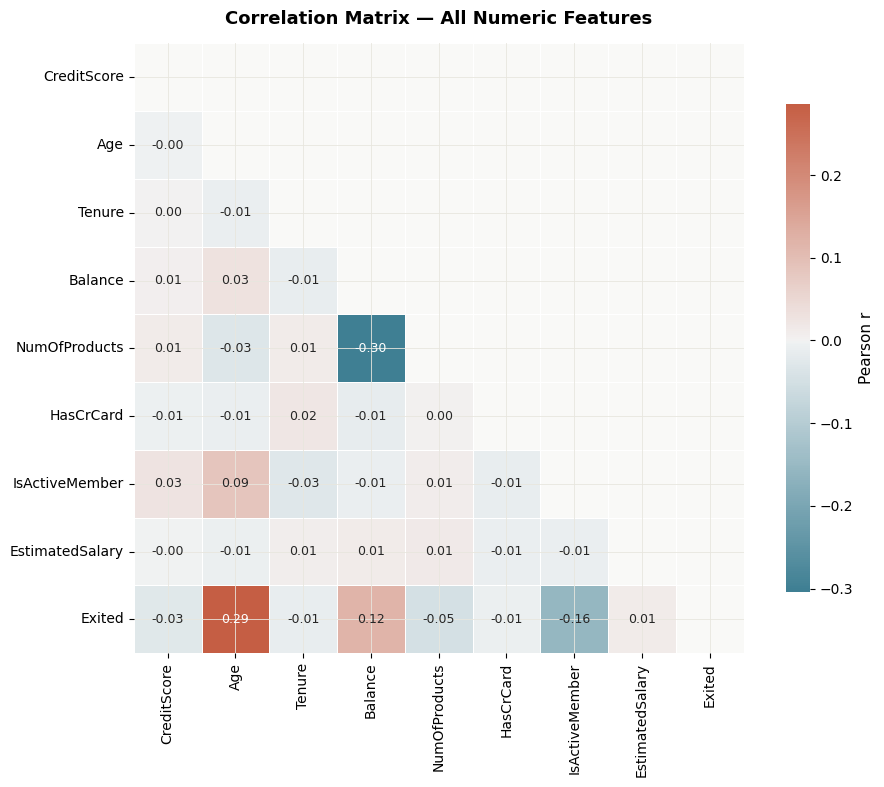


Top correlations with Exited (churn):
────────────────────────────────────────
  Age                  +0.285
  IsActiveMember       –0.156
  Balance              +0.119
  NumOfProducts        –0.048
  CreditScore          –0.027
  Tenure               –0.014
  EstimatedSalary      +0.012
  HasCrCard            –0.007


In [9]:
NUMERIC_FEATS = ['CreditScore','Age','Tenure','Balance','NumOfProducts',
                 'HasCrCard','IsActiveMember','EstimatedSalary','Exited']

corr = df[NUMERIC_FEATS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))

cmap = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(
    corr, mask=mask, cmap=cmap, center=0,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    linewidths=0.5, linecolor='white',
    square=True, ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)

ax.set_title('Correlation Matrix — All Numeric Features', fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('fig_03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with Exited
print('\nTop correlations with Exited (churn):')
print('─' * 40)
top_corr = corr['Exited'].drop('Exited').abs().sort_values(ascending=False)
for feat, val in top_corr.items():
    direction = '+' if corr['Exited'][feat] > 0 else '–'
    print(f'  {feat:<20} {direction}{val:.3f}')